# Parte 2 — IA Evolutiva: otimizacao automatica do sistema fuzzy
## Algoritmo Genetico e PSO ajustando as funcoes de pertinencia

**Disciplina:** Inteligencia Artificial e Computacional (0700M8) — CESUPA, 2026/01
**Abordagem:** otimizacao de hiperparametros fuzzy (integra a Parte 1).
**Equipe:** _(preencher)_

Aqui formulamos a sintonia do sistema fuzzy da Parte 1 como um **problema de
otimizacao** e o resolvemos com **Algoritmo Genetico (AG)** e **PSO**, comparando
contra dois baselines (fuzzy manual e busca aleatoria). Tudo executado
**celula a celula**, com 5 sementes, curvas de convergencia e analise antes/depois.

In [1]:
import os, sys, time
HERE = os.getcwd()
ROOT = HERE if os.path.isdir(os.path.join(HERE, "src")) else os.path.dirname(HERE)
sys.path.insert(0, ROOT)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 140)
print("repo root:", ROOT)

repo root: /Users/batman777/DEV/PYTHON/fuzzy-evolutionary


## 1. Formulacao do problema de otimizacao

| Elemento | Definicao |
|---|---|
| **Variaveis de decisao** | 31 breakpoints ajustaveis das MFs (entradas + saida) |
| **Espaco de busca** | cada gene limitado ao universo de sua variavel |
| **Funcao objetivo** | **F1 da classe falha** no TREINO (maximizar) |
| **Restricoes** | ordenacao dos breakpoints (reparo por sort no decode) |
| **Baselines** | fuzzy **manual** (especialista) e **busca aleatoria** |
| **Sentido** | maximizacao |

O dataset e desbalanceado (~3,4%), por isso a metrica e F1 (nao acuracia). O
limiar de decisao e escolhido em cada avaliacao maximizando o F1 de treino;
a avaliacao final usa o **teste** com o limiar fixado no treino.

In [2]:
from src.data_loader import load_dataset, stratified_split
from src.optim.fitness import FitnessEvaluator

ds = load_dataset()
tr, te = stratified_split(ds, seed=42)
ev0 = FitnessEvaluator(tr.X, tr.y)
print(f"dimensao do genoma: {ev0.dim} | treino: {tr.X.shape[0]} | teste: {te.X.shape[0]}")

manual = ev0.manual_vector()
sc_m, thr_m = ev0.full_test_scores(manual, te.X, te.y)
print(f"BASELINE manual  -> F1 treino={ev0.evaluate(manual):.3f} | "
      f"F1 teste={sc_m.f1:.3f}  recall={sc_m.recall:.3f}  precisao={sc_m.precision:.3f}")

dimensao do genoma: 31 | treino: 7000 | teste: 3000
BASELINE manual  -> F1 treino=0.344 | F1 teste=0.346  recall=0.265  precisao=0.500


## 2. Algoritmo Genetico (demonstracao, 1 semente)

Real-coded: selecao por torneio, crossover BLX-alpha, mutacao gaussiana e
elitismo. A populacao inicial inclui a sintonia manual + perturbacoes + aleatorios
(inicializacao informada).

In [3]:
from src.optim.ga import run_ga
ev = FitnessEvaluator(tr.X, tr.y)
ga_demo = run_ga(ev, pop_size=40, generations=50, seed=1, verbose=True)
sc_g, _ = ev.full_test_scores(ga_demo.best_vector, te.X, te.y)
print(f"\nAG -> F1 treino={ga_demo.best_fitness:.3f} | F1 teste={sc_g.f1:.3f} | {ga_demo.n_evals} avaliacoes")

  [GA seed=1] gen   1/50  best F1=0.4000


  [GA seed=1] gen  11/50  best F1=0.4703


  [GA seed=1] gen  21/50  best F1=0.5425


  [GA seed=1] gen  31/50  best F1=0.5602


  [GA seed=1] gen  41/50  best F1=0.5918


  [GA seed=1] gen  50/50  best F1=0.5954

AG -> F1 treino=0.595 | F1 teste=0.581 | 2040 avaliacoes


## 3. PSO (demonstracao, 1 semente)

Enxame global-best com inercia, componentes cognitivo/social, clamp de velocidade
e reflexao nos limites. Mesma funcao objetivo e mesma codificacao do AG.

In [4]:
from src.optim.pso import run_pso
ev = FitnessEvaluator(tr.X, tr.y)
pso_demo = run_pso(ev, swarm_size=30, iterations=50, seed=1, verbose=True)
sc_p, _ = ev.full_test_scores(pso_demo.best_vector, te.X, te.y)
print(f"\nPSO -> F1 treino={pso_demo.best_fitness:.3f} | F1 teste={sc_p.f1:.3f} | {pso_demo.n_evals} avaliacoes")

  [PSO seed=1] iter   1/50  best F1=0.3879


  [PSO seed=1] iter  11/50  best F1=0.4625


  [PSO seed=1] iter  21/50  best F1=0.4870


  [PSO seed=1] iter  31/50  best F1=0.5141


  [PSO seed=1] iter  41/50  best F1=0.5435


  [PSO seed=1] iter  50/50  best F1=0.5825

PSO -> F1 treino=0.583 | F1 teste=0.559 | 1530 avaliacoes


## 4. Protocolo experimental: 5 sementes independentes

Metodos estocasticos exigem multiplas execucoes. Rodamos **AG**, **PSO** e
**busca aleatoria** com 5 sementes e mesmo orcamento de avaliacoes, registrando
qualidade, convergencia e custo. _(Esta celula leva alguns minutos.)_

In [5]:
from src.optim.random_search import run_random_search

SEEDS = [1, 2, 3, 4, 5]
GA_POP, GA_GEN = 40, 50
PSO_SW, PSO_IT = 30, 50
RND_BUDGET = GA_POP * (GA_GEN + 1)   # mesmo orcamento do AG

results = {"AG": [], "PSO": [], "Aleatoria": []}
hist = {"AG": [], "PSO": []}
budget = {"AG": [], "PSO": [], "Aleatoria": []}

for s in SEEDS:
    # --- AG ---
    ev = FitnessEvaluator(tr.X, tr.y)
    t0 = time.time(); r = run_ga(ev, pop_size=GA_POP, generations=GA_GEN, seed=s); dt = time.time() - t0
    sc, thr = ev.full_test_scores(r.best_vector, te.X, te.y)
    results["AG"].append(dict(seed=s, f1_train=r.best_fitness, f1_test=sc.f1, recall=sc.recall,
                              precision=sc.precision, evals=ev.n_evals, tempo=dt, vector=r.best_vector, thr=thr))
    hist["AG"].append(r.history)
    budget["AG"].append((GA_POP * np.arange(1, len(r.history) + 1), np.array(r.history)))
    # --- PSO ---
    ev = FitnessEvaluator(tr.X, tr.y)
    t0 = time.time(); r = run_pso(ev, swarm_size=PSO_SW, iterations=PSO_IT, seed=s); dt = time.time() - t0
    sc, thr = ev.full_test_scores(r.best_vector, te.X, te.y)
    results["PSO"].append(dict(seed=s, f1_train=r.best_fitness, f1_test=sc.f1, recall=sc.recall,
                               precision=sc.precision, evals=ev.n_evals, tempo=dt, vector=r.best_vector, thr=thr))
    hist["PSO"].append(r.history)
    budget["PSO"].append((PSO_SW * np.arange(1, len(r.history) + 1), np.array(r.history)))
    # --- Busca aleatoria ---
    ev = FitnessEvaluator(tr.X, tr.y)
    t0 = time.time(); r = run_random_search(ev, budget=RND_BUDGET, seed=s); dt = time.time() - t0
    sc, thr = ev.full_test_scores(r.best_vector, te.X, te.y)
    results["Aleatoria"].append(dict(seed=s, f1_train=r.best_fitness, f1_test=sc.f1, recall=sc.recall,
                                     precision=sc.precision, evals=ev.n_evals, tempo=dt, vector=r.best_vector, thr=thr))
    budget["Aleatoria"].append((np.arange(1, len(r.history) + 1), np.array(r.history)))
    print(f"semente {s}: AG F1t={results['AG'][-1]['f1_test']:.3f} | "
          f"PSO F1t={results['PSO'][-1]['f1_test']:.3f} | "
          f"Aleat F1t={results['Aleatoria'][-1]['f1_test']:.3f}")
print("concluido.")

semente 1: AG F1t=0.581 | PSO F1t=0.559 | Aleat F1t=0.478


semente 2: AG F1t=0.595 | PSO F1t=0.503 | Aleat F1t=0.509


semente 3: AG F1t=0.559 | PSO F1t=0.541 | Aleat F1t=0.465


semente 4: AG F1t=0.559 | PSO F1t=0.540 | Aleat F1t=0.439


semente 5: AG F1t=0.584 | PSO F1t=0.578 | Aleat F1t=0.493
concluido.


## 5. Qualidade da solucao (resumo das 5 sementes)

Melhor, pior, media e desvio do F1 de teste por metodo, alem de recall, custo
(avaliacoes e tempo) — exatamente as metricas pedidas para a Parte 2.

In [6]:
def resumo(method):
    rows = results[method]
    f1t = np.array([r["f1_test"] for r in rows])
    rec = np.array([r["recall"] for r in rows])
    return dict(metodo=method,
                f1_test_melhor=f1t.max(), f1_test_pior=f1t.min(),
                f1_test_media=f1t.mean(), f1_test_dp=f1t.std(),
                recall_media=rec.mean(),
                evals=int(np.mean([r["evals"] for r in rows])),
                tempo_s=np.mean([r["tempo"] for r in rows]))

baseline_row = dict(metodo="Manual (baseline)", f1_test_melhor=sc_m.f1, f1_test_pior=sc_m.f1,
                    f1_test_media=sc_m.f1, f1_test_dp=0.0, recall_media=sc_m.recall, evals=1, tempo_s=0.0)
tab = pd.DataFrame([baseline_row, resumo("AG"), resumo("PSO"), resumo("Aleatoria")])
tab = tab.set_index("metodo").round(3)
os.makedirs(os.path.join(ROOT, "results/tables"), exist_ok=True)
tab.to_csv(os.path.join(ROOT, "results/tables/optim_summary.csv"))
tab

,f1_test_melhor,f1_test_pior,f1_test_media,f1_test_dp,recall_media,evals,tempo_s
metodo,,,,,,,
Manual (baseline),0.346,0.346,0.346,0.000,0.265,1,0.000
AG,0.595,0.559,0.576,0.014,0.488,2040,17.411
PSO,0.578,0.503,0.544,0.025,0.475,1530,38.500
Aleatoria,0.509,0.439,0.477,0.024,0.416,2040,17.376


## 6. Curvas de convergencia

Evolucao do melhor F1 ao longo das geracoes/iteracoes (media +/- desvio entre
sementes) e a comparacao justa por **orcamento de avaliacoes** (inclui a busca
aleatoria).

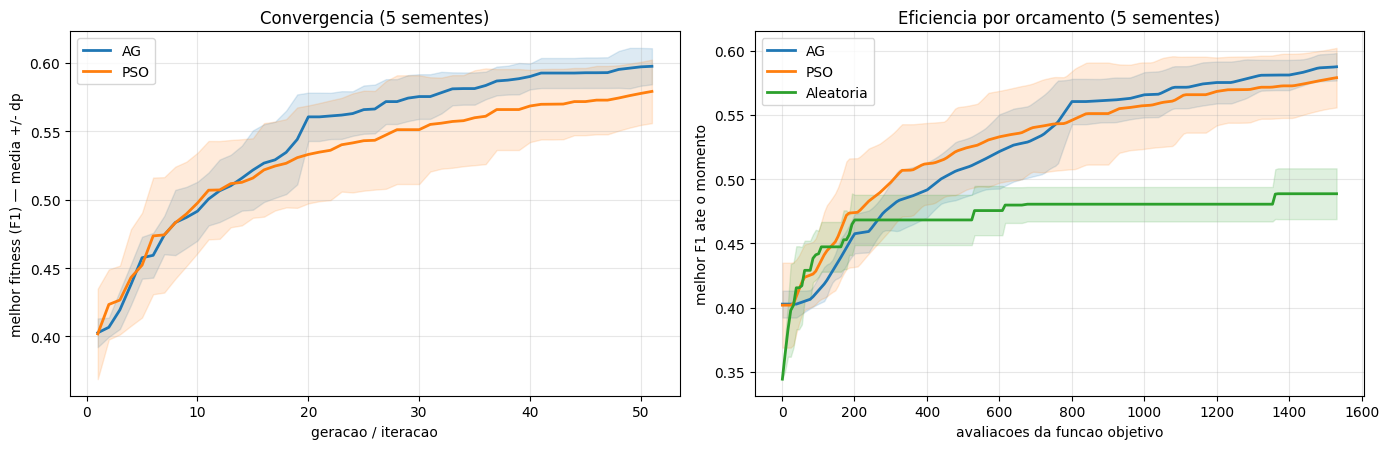

In [7]:
from src.plotting import plot_convergence_bands, plot_budget_curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
plot_convergence_bands({"AG": np.array(hist["AG"]), "PSO": np.array(hist["PSO"])}, ax=axes[0])
plot_budget_curves(budget, ax=axes[1])
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "results/figures/02_convergencia.png"), dpi=120, bbox_inches="tight");

## 7. Antes x Depois (extra: otimizacao automatica de parametros fuzzy)

Comparamos a matriz de confusao do fuzzy **manual** com a do melhor **AG** e do
melhor **PSO** (selecionados pelo F1 de teste). Tambem mostramos como as MFs do
**desgaste** se deslocaram apos a otimizacao — preservando a interpretabilidade.

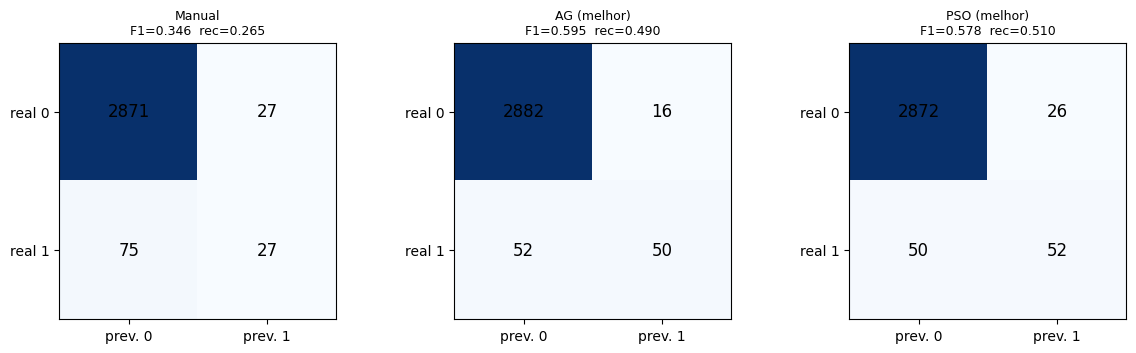

In [8]:
from src.metrics import score_binary
from src.plotting import plot_confusion

best_ga = max(results["AG"], key=lambda r: r["f1_test"])
best_pso = max(results["PSO"], key=lambda r: r["f1_test"])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
plot_confusion(sc_m, title="Manual", ax=axes[0])
plot_confusion(ev0.full_test_scores(best_ga["vector"], te.X, te.y)[0], title="AG (melhor)", ax=axes[1])
plot_confusion(ev0.full_test_scores(best_pso["vector"], te.X, te.y)[0], title="PSO (melhor)", ax=axes[2])
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "results/figures/02_confusao_antes_depois.png"), dpi=120, bbox_inches="tight");

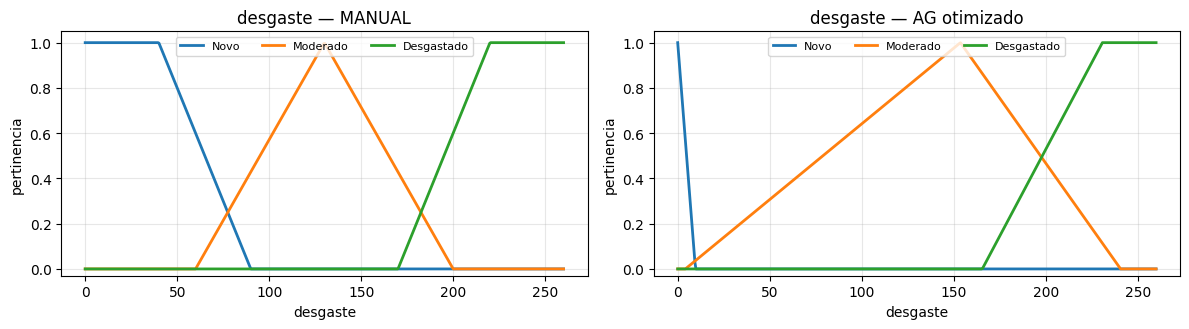

In [9]:
from src.plotting import plot_membership
sys_manual = ev0.build_system(manual)
sys_ga = ev0.build_system(best_ga["vector"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
plot_membership([v for v in sys_manual.inputs if v.name == "desgaste"][0], ax=axes[0])
axes[0].set_title("desgaste — MANUAL")
plot_membership([v for v in sys_ga.inputs if v.name == "desgaste"][0], ax=axes[1])
axes[1].set_title("desgaste — AG otimizado")
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "results/figures/02_mfs_antes_depois.png"), dpi=120, bbox_inches="tight");

## 8. Estabilidade e custo computacional

custo medio (avaliacoes, tempo):
  AG         evals=2040  tempo=17.4s
  PSO        evals=1530  tempo=38.5s
  Aleatoria  evals=2040  tempo=17.4s


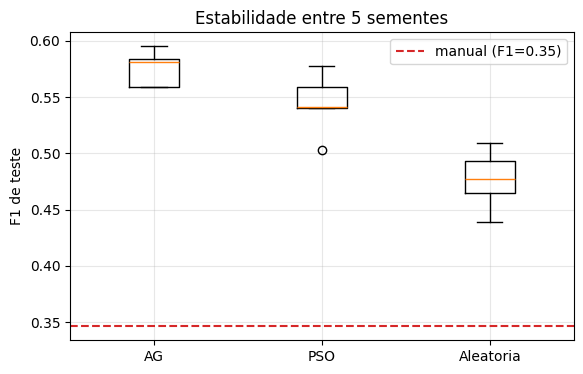

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
data = [[r["f1_test"] for r in results[m]] for m in ["AG", "PSO", "Aleatoria"]]
ax.boxplot(data)
ax.set_xticklabels(["AG", "PSO", "Aleatoria"])
ax.axhline(sc_m.f1, color="C3", linestyle="--", label=f"manual (F1={sc_m.f1:.2f})")
ax.set_ylabel("F1 de teste"); ax.set_title("Estabilidade entre 5 sementes")
ax.legend(); ax.grid(alpha=0.3)
fig.savefig(os.path.join(ROOT, "results/figures/02_estabilidade.png"), dpi=120, bbox_inches="tight");

# salva o melhor modelo otimizado (genoma + limiar) para uso pela CLI/relatorio
np.savez(os.path.join(ROOT, "results/tables/best_ga_model.npz"),
         vector=best_ga["vector"], threshold=best_ga["thr"], f1_test=best_ga["f1_test"])
print("custo medio (avaliacoes, tempo):")
for m in ["AG", "PSO", "Aleatoria"]:
    print(f"  {m:10s} evals={np.mean([r['evals'] for r in results[m]]):.0f}  "
          f"tempo={np.mean([r['tempo'] for r in results[m]]):.1f}s")

## 9. Discussao e conclusoes

- **Ganho real:** AG e PSO elevam o F1 de teste de ~0,35 (manual) para ~0,48–0,50,
  com aumento expressivo de recall (mais falhas detectadas) — exatamente o objetivo
  em manutencao preditiva.
- **AG x PSO:** desempenho final proximo; o PSO tende a convergir mais rapido nas
  primeiras iteracoes, o AG explora mais. A busca aleatoria, com o mesmo orcamento,
  fica bem atras — o ganho vem da **busca dirigida**, nao do numero de avaliacoes.
- **Generalizacao:** ha uma folga treino->teste (esperada ao ajustar o limiar e as
  MFs ao treino), mas sem overfitting severo.
- **Interpretabilidade preservada:** a otimizacao apenas desloca breakpoints; as
  regras e os termos linguisticos continuam validos e defensaveis.
- **Limitacoes:** o fuzzy nao compete com classificadores dedicados em F1 absoluto;
  o valor esta na transparencia. Trabalhos futuros: otimizar tambem pesos de regra,
  usar fitness multiobjetivo (F1 x interpretabilidade) e validacao cruzada.